# Q2 Yield Curve Review | Markets Mondays



# 1. Introduction

This project examines how the U.S. Treasury yield curve evolved during the second quarter of 2026, covering the period from April 1 through June 30. Using daily Treasury yield data from the Federal Reserve Economic Data (FRED) database, the analysis focuses on five key maturities: 3-month, 2-year, 5-year, 10-year, and 30-year securities.

The study evaluates both the direction and structure of interest-rate movements during the quarter. It measures changes in yields across maturities, compares the yield curve at the beginning and end of Q2, analyzes the 2Y–10Y spread, and examines rolling volatility. Additional analysis uses principal component analysis to identify the level, slope, and curvature factors driving yield-curve movements.

The main objectives are to determine:

- Which Treasury maturities experienced the greatest repricing
- Whether the yield curve steepened or flattened during Q2
- How interest-rate volatility changed throughout the quarter
- What Treasury-market movements suggested about Federal Reserve policy, inflation, and economic growth
- How Q2 developments compared with the yield-curve dynamics observed in Q1

The project combines quantitative analysis, data visualization, and macroeconomic interpretation to produce an accessible but research-oriented review of the U.S. rates market.

**Author:** Ian Chigada  
**Focus:** Quantitative Macro & Rates Research  
**Data source:** Federal Reserve Economic Data (FRED)

# 2. Data Collection and Preparation

## installing and importing packages

In [26]:
!pip install pandas_datareader --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from datetime import datetime

import os

# Creating project folders
os.makedirs("charts", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("report", exist_ok=True)

## Defining Q2 Dates and Treasury tickers

In [27]:
start_date = "2026-04-01"
end_date = "2026-06-30"

treasury_series = {
    "3M": "DGS3MO",
    "2Y": "DGS2",
    "5Y": "DGS5",
    "10Y": "DGS10",
    "30Y": "DGS30"
}

## Pulling Treasury Data from FRED

In [28]:
yields = pd.DataFrame()

for maturity, fred_code in treasury_series.items():
    yields[maturity] = pdr.DataReader(fred_code, "fred", start_date, end_date)[fred_code]

yields = yields.dropna()

yields.head()

,3M,2Y,5Y,10Y,30Y
DATE,,,,,
2026-04-01,3.70,3.81,3.97,4.33,4.91
2026-04-02,3.70,3.79,3.94,4.31,4.88
2026-04-03,3.71,3.84,3.99,4.35,4.91
2026-04-06,3.72,3.84,3.98,4.34,4.89
2026-04-07,3.71,3.81,3.95,4.33,4.90


## Inspecting and Cleaning the Data

In [29]:
# Inspecting the data
yields.info()

# Converting index to datetime if needed
yields.index = pd.to_datetime(yields.index)

# Displaying first few rows
yields.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63 entries, 2026-04-01 to 2026-06-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   3M      63 non-null     float64
 1   2Y      63 non-null     float64
 2   5Y      63 non-null     float64
 3   10Y     63 non-null     float64
 4   30Y     63 non-null     float64
dtypes: float64(5)
memory usage: 3.0 KB


,3M,2Y,5Y,10Y,30Y
DATE,,,,,
2026-04-01,3.70,3.81,3.97,4.33,4.91
2026-04-02,3.70,3.79,3.94,4.31,4.88
2026-04-03,3.71,3.84,3.99,4.35,4.91
2026-04-06,3.72,3.84,3.98,4.34,4.89
2026-04-07,3.71,3.81,3.95,4.33,4.90


# 3. Yield Curve Analysis

## Plotting the Entire Q2 Yield Curves

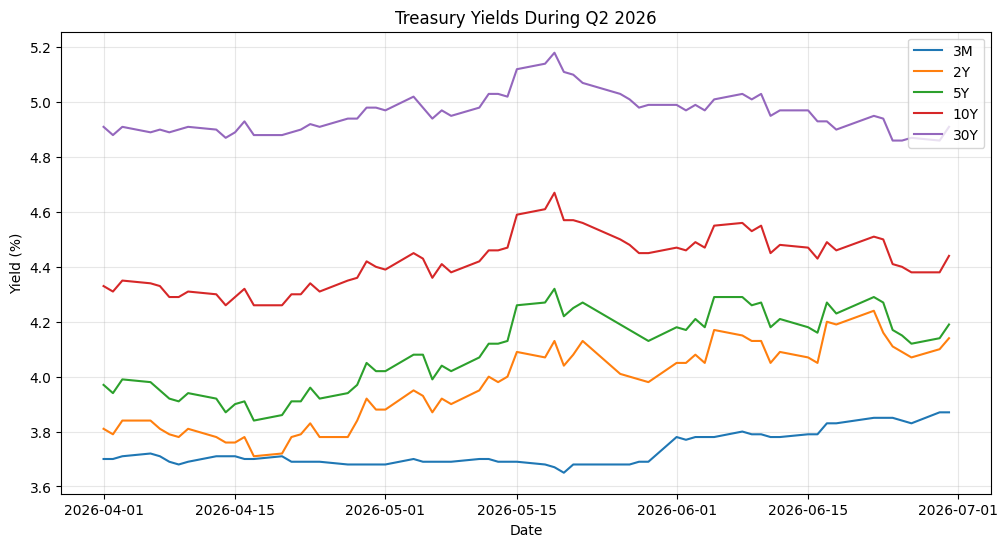

In [30]:
plt.figure(figsize=(12,6))

for col in yields.columns:
    plt.plot(yields.index, yields[col], label=col)

plt.title("Treasury Yields During Q2 2026")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Figure 1: Treasury Yield Evolution During Q2 2026

**Figure 1.** Daily U.S. Treasury yields across five maturities (3M, 2Y, 5Y, 10Y, and 30Y) during Q2 2026. The time series highlights how different segments of the yield curve responded to evolving market expectations for Federal Reserve policy, inflation, and economic growth throughout the quarter.

## Beginning vs. End of Q2 Yield Curve

Comparing the Treasury yield curve at the beginning and end of the quarter highlights how market expectations evolved across maturities. Changes in the curve's shape provide insight into shifting expectations for Federal Reserve policy, inflation, and long-term economic growth.

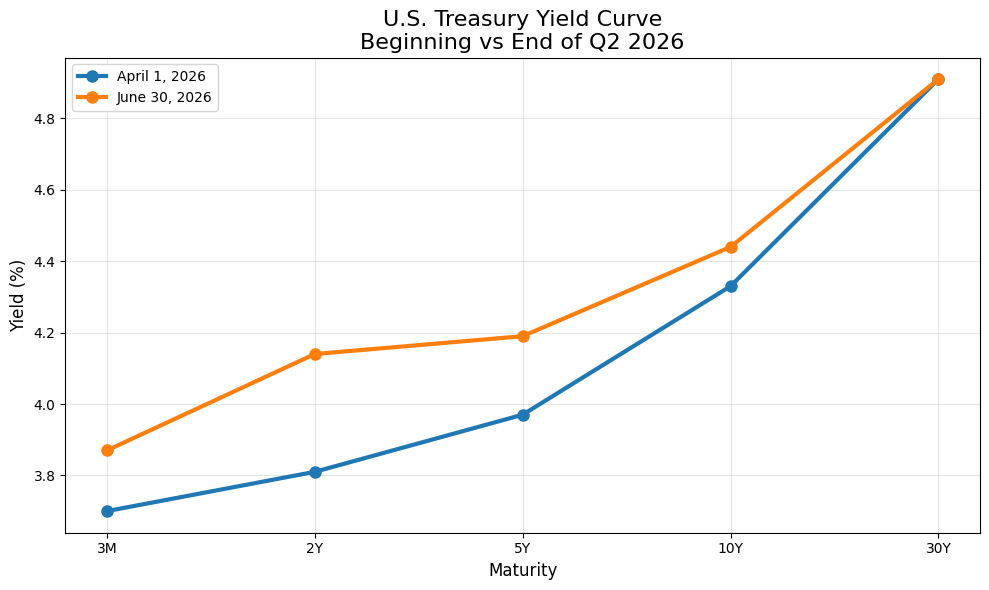

In [31]:
# Treasury maturities (ordered)
maturities = ["3M", "2Y", "5Y", "10Y", "30Y"]

# First and last trading day of the quarter
start_curve = yields.iloc[0]
end_curve = yields.iloc[-1]

plt.figure(figsize=(10,6))

plt.plot(
    maturities,
    start_curve,
    marker='o',
    linewidth=3,
    markersize=8,
    label="April 1, 2026"
)

plt.plot(
    maturities,
    end_curve,
    marker='o',
    linewidth=3,
    markersize=8,
    label="June 30, 2026"
)

plt.title("U.S. Treasury Yield Curve\nBeginning vs End of Q2 2026", fontsize=16)

plt.xlabel("Maturity", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()

##Figure 2: Beginning vs. End of Q2 Yield Curve

**Figure 2** Comparison of the U.S. Treasury yield curve on the first and last trading days of Q2 2026. The shift in the curve illustrates how yields repriced across maturities over the quarter, providing insight into changes in monetary policy expectations and the market's long-term economic outlook.

## Yield Changes Across Maturities

To quantify the shift in the Treasury curve, we compute the change in yields between the first and last trading day of Q2.

Because fixed-income markets measure interest rate movements in **basis points (bps)**, all changes are reported in bps (1 bp = 0.01%).

### Calculating Changes

In [32]:
# First and last observations
start_curve = yields.iloc[0]
end_curve = yields.iloc[-1]

# Summary table
summary = pd.DataFrame({
    "Start Yield (%)": start_curve,
    "End Yield (%)": end_curve
})

summary["Change (bps)"] = (
    (summary["End Yield (%)"] - summary["Start Yield (%)"]) * 100
).round(1)

summary

,Start Yield (%),End Yield (%),Change (bps)
3M,3.70,3.87,17.0
2Y,3.81,4.14,33.0
5Y,3.97,4.19,22.0
10Y,4.33,4.44,11.0
30Y,4.91,4.91,0.0


### Bar Chart of Yield Changes

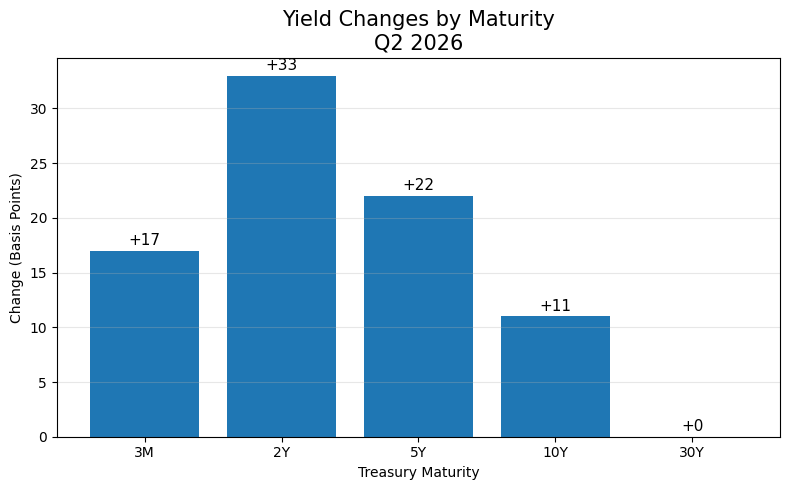

In [33]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    summary.index,
    summary["Change (bps)"]
)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"+{height:.0f}",
        ha='center',
        fontsize=11
    )

plt.title("Yield Changes by Maturity\nQ2 2026", fontsize=15)
plt.xlabel("Treasury Maturity")
plt.ylabel("Change (Basis Points)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Figure 3: Quantify Yield Changes (Basis Points)
**Figure 3.** Change in U.S. Treasury yields across maturities between April 1 and June 30, 2026, measured in basis points (bps). The 2-year Treasury yield experienced the largest increase (+33 bps), indicating that short-term interest rate expectations were repriced more aggressively than long-term expectations. In contrast, the 30-year yield remained unchanged, suggesting relatively stable long-run inflation and growth expectations.

### Key Observations

- The **2-year Treasury** recorded the largest increase (+33 bps), reflecting significant repricing of Federal Reserve policy expectations.
- Intermediate maturities (5Y) also moved higher, though less sharply than the front end.
- Long-term yields changed relatively little, with the **30-year Treasury finishing the quarter unchanged**, suggesting long-run inflation expectations remained well anchored.
- Overall, the repricing was concentrated in the **front and intermediate segments** of the yield curve.

# 4. Yield Spread Analysis

The spread between the 10-year and 2-year Treasury yields is one of the most closely watched indicators in fixed-income markets. It provides insight into market expectations for future economic growth, inflation, and monetary policy. Changes in the spread help determine whether the yield curve is steepening or flattening over time.

### 4.1 Calculating the 2Y–10Y Treasury Spread

The **2Y–10Y spread** is calculated as the difference between the 10-year and 2-year Treasury yields:

$$
\text{2Y–10Y Spread} = Y_{10Y} - Y_{2Y}
$$

where:

- $Y_{10Y}$ = 10-year Treasury yield
- $Y_{2Y}$ = 2-year Treasury yield

A positive spread generally indicates a normal upward-sloping yield curve, while a narrowing or negative spread reflects a flatter or inverted yield curve.

In [34]:
# Calculating the 2Y–10Y spread
yields["2Y_10Y_Spread"] = (
    yields["10Y"] - yields["2Y"]
).round(2)

yields.head()

,3M,2Y,5Y,10Y,30Y,2Y_10Y_Spread
DATE,,,,,,
2026-04-01,3.70,3.81,3.97,4.33,4.91,0.52
2026-04-02,3.70,3.79,3.94,4.31,4.88,0.52
2026-04-03,3.71,3.84,3.99,4.35,4.91,0.51
2026-04-06,3.72,3.84,3.98,4.34,4.89,0.50
2026-04-07,3.71,3.81,3.95,4.33,4.90,0.52


### 4.2 Evolution of the 2Y–10Y Spread

This figure tracks the daily difference between the 10-year and 2-year Treasury yields throughout Q2 2026. Changes in the spread illustrate whether the yield curve became steeper or flatter over the course of the quarter.

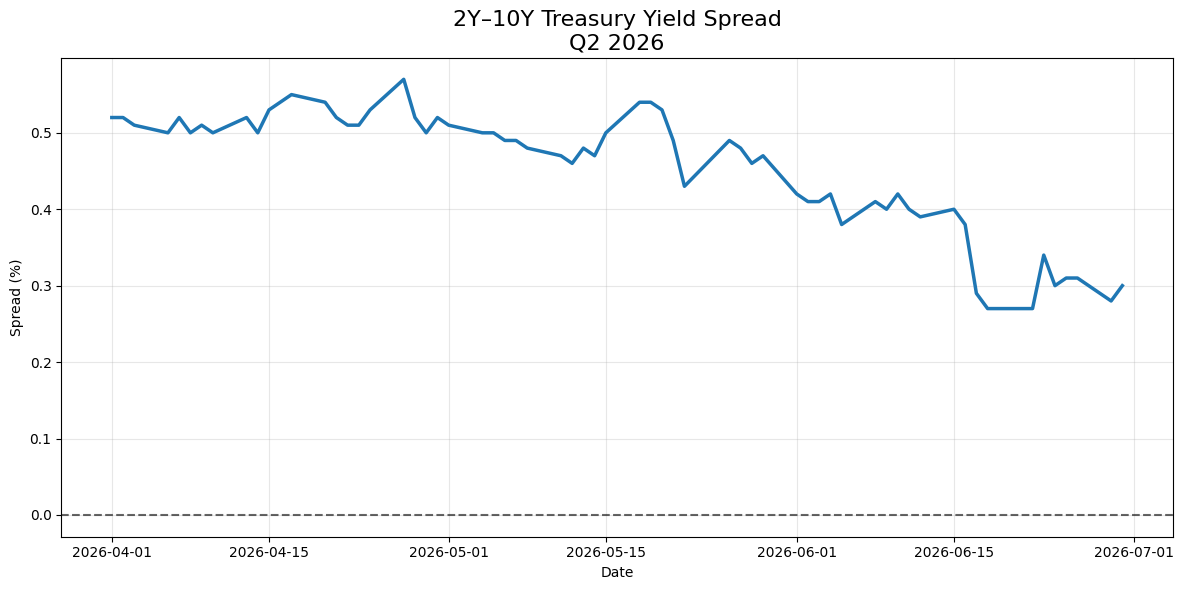

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    yields.index,
    yields["2Y_10Y_Spread"],
    linewidth=2.5
)

plt.axhline(0, color="black", linestyle="--", alpha=0.6)

plt.title("2Y–10Y Treasury Yield Spread\nQ2 2026", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Spread (%)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Figure 4.** Daily 2Y–10Y Treasury yield spread during Q2 2026. The spread measures the difference between the 10-year and 2-year Treasury yields and serves as a widely followed indicator of market expectations for future economic growth and monetary policy. A narrowing spread indicates a flattening yield curve, while a widening spread reflects a steepening curve.

### 4.3 Summary Statistics of the 2Y–10Y Spread

Descriptive statistics provide a quantitative summary of the behavior of the 2Y–10Y Treasury spread throughout Q2 2026. These measures capture the average spread, its variability, and the range over which the yield curve evolved during the quarter.



In [36]:
spread = yields["2Y_10Y_Spread"]

spread.describe().round(3)

,2Y_10Y_Spread
count,63.000
mean,0.456
std,0.080
min,0.270
25%,0.410
50%,0.490
75%,0.515
max,0.570


### Interpretation

The average 2Y–10Y Treasury spread during Q2 2026 was **45.6 basis points**, with values ranging from a low of **27 basis points** to a high of **57 basis points**.

The spread exhibited relatively low variability, with a standard deviation of **8 basis points**, indicating that although the yield curve flattened over the quarter, the adjustment occurred gradually rather than through large daily swings.

The decline in the spread from its early-quarter highs toward quarter-end suggests that short-term Treasury yields increased more rapidly than long-term yields. This pattern is consistent with a market that increasingly priced in higher near-term policy rates while maintaining relatively stable long-term expectations for inflation and economic growth.

### What These Numbers Mean

| Statistic           | Interpretation                                                                           |
| ------------------- | ---------------------------------------------------------------------------------------- |
| **Mean = 45.6 bps** | The yield curve remained positively sloped on average throughout Q2.                     |
| **Min = 27 bps**    | The flattest point of the quarter occurred toward late June.                             |
| **Max = 57 bps**    | The curve was steepest in late April.                                                    |
| **Std = 8 bps**     | Changes in the spread were moderate and relatively orderly.                              |
| **Median = 49 bps** | The spread spent much of the quarter around 50 bps before flattening toward quarter-end. |


### 4.4 Change in the 2Y–10Y Spread

Comparing the spread at the beginning and end of the quarter provides a concise measure of how the yield curve evolved over Q2 2026.

A decline in the spread indicates that the yield curve flattened, meaning short-term Treasury yields increased more rapidly than long-term yields.

In [37]:
start_spread = spread.iloc[0]
end_spread = spread.iloc[-1]
spread_change = (end_spread - start_spread) * 100

summary_spread = pd.DataFrame({
    "Metric": [
        "Start of Q2",
        "End of Q2",
        "Quarter Change"
    ],
    "Value": [
        f"{start_spread:.2f}% ({start_spread*100:.0f} bps)",
        f"{end_spread:.2f}% ({end_spread*100:.0f} bps)",
        f"{spread_change:.1f} bps"
    ]
})

summary_spread

,Metric,Value
0,Start of Q2,0.52% (52 bps)
1,End of Q2,0.30% (30 bps)
2,Quarter Change,-22.0 bps


### Discussion

The 2Y–10Y Treasury spread narrowed from **52 basis points** at the beginning of Q2 to **30 basis points** by quarter-end, representing a **22-basis-point flattening** of the yield curve.

This flattening occurred because short-term Treasury yields increased substantially more than long-term yields during the quarter. The result suggests that investors revised expectations for near-term Federal Reserve policy while maintaining relatively stable long-term expectations for inflation and economic growth.

Although the yield curve remained positively sloped throughout Q2, the reduction in the spread indicates that the difference between long- and short-term borrowing costs narrowed considerably over the course of the quarter.

## Section Summary

The yield spread analysis showed that the Treasury curve flattened during Q2 2026.

Key findings include:

- The average 2Y–10Y spread was **45.6 basis points**.
- The spread ranged between **27 and 57 basis points**.
- The curve flattened by **22 basis points** over the quarter.
- The flattening was driven primarily by a larger increase in the 2-year Treasury yield relative to the 10-year yield.

# 5. Yield Curve Risk and Volatility

Interest rate volatility measures the magnitude of fluctuations in Treasury yields over time. Periods of elevated volatility often coincide with heightened uncertainty surrounding monetary policy, inflation expectations, or macroeconomic developments.

To assess changes in market risk during Q2 2026, this section computes the rolling volatility of Treasury yields across different maturities.

## 5.1 Calculating Rolling Volatility

Rolling volatility is computed as the rolling standard deviation of daily Treasury yields over a fixed window.

For each maturity,

$$
\sigma_t = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(y_i-\bar y)^2}
$$

where

- $\sigma_t$ is the rolling volatility
- $y_i$ is the Treasury yield
- $\bar y$ is the rolling average yield
- $n$ is the rolling window length

A **20-day rolling window** is used, approximating one trading month.

In [38]:
# Calculating 20-day rolling volatility

rolling_vol = yields[["3M","2Y","5Y","10Y","30Y"]].rolling(window=20).std()

rolling_vol.head()

,3M,2Y,5Y,10Y,30Y
DATE,,,,,
2026-04-01,NaN,NaN,NaN,NaN,NaN
2026-04-02,NaN,NaN,NaN,NaN,NaN
2026-04-03,NaN,NaN,NaN,NaN,NaN
2026-04-06,NaN,NaN,NaN,NaN,NaN
2026-04-07,NaN,NaN,NaN,NaN,NaN


## 5.2 Rolling Volatility of Treasury Yields

The figure below shows the 20-day rolling standard deviation of Treasury yields across maturities during Q2 2026.

Higher values indicate periods of greater interest rate volatility and increased market uncertainty.

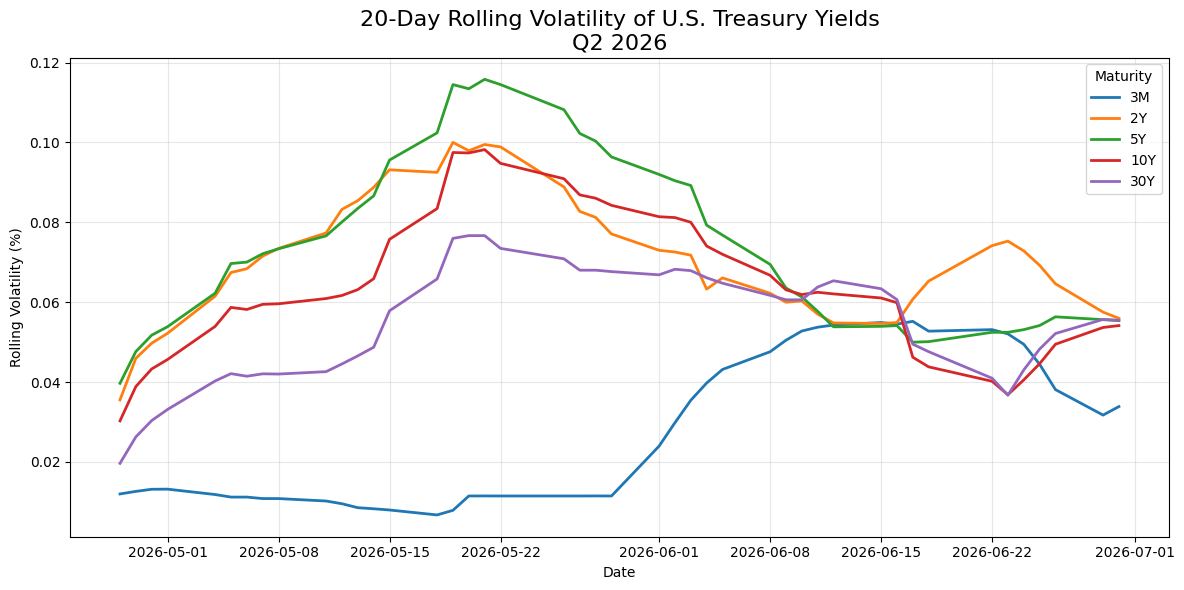

In [39]:
plt.figure(figsize=(12,6))

for maturity in rolling_vol.columns:
    plt.plot(
        rolling_vol.index,
        rolling_vol[maturity],
        linewidth=2,
        label=maturity
    )

plt.title(
    "20-Day Rolling Volatility of U.S. Treasury Yields\nQ2 2026",
          fontsize=16
          )

plt.xlabel("Date")
plt.ylabel("Rolling Volatility (%)")

plt.grid(alpha=0.3)

plt.legend(title="Maturity")

plt.tight_layout()
plt.savefig(
    "charts/figure5_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 5.** Twenty-day rolling volatility of U.S. Treasury yields across five maturities during Q2 2026. Rolling volatility measures the variability of Treasury yields over a one-month trading window and provides insight into changes in interest-rate risk and market uncertainty throughout the quarter.

### Interpretation

The rolling volatility analysis reveals that interest-rate volatility varied considerably across Treasury maturities during Q2 2026.

Intermediate-term maturities, particularly the **5-year Treasury**, exhibited the highest levels of volatility during May, indicating that this segment of the yield curve was the most responsive to changing market expectations. The **2-year and 10-year Treasuries** also experienced elevated volatility, reflecting the market's reassessment of the Federal Reserve's policy outlook.

In contrast, the **3-month Treasury** remained relatively stable throughout much of the quarter, with volatility increasing only toward June. The **30-year Treasury** displayed comparatively moderate fluctuations, suggesting that long-term inflation and growth expectations remained relatively well anchored despite changes in short- and intermediate-term rates.

Overall, volatility peaked in the middle of the quarter before gradually declining, indicating that market uncertainty eased as Q2 progressed.

### Key Observations

- The **5-year Treasury** recorded the highest rolling volatility during Q2.
- Volatility across most maturities peaked during **mid-May**.
- Short-term yields (2Y) exhibited greater volatility than long-term yields (30Y).
- The **3-month Treasury** remained relatively stable until late in the quarter.
- Interest-rate volatility generally declined toward quarter-end, suggesting reduced market uncertainty.

# 6. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical technique used to identify the dominant factors driving movements in the Treasury yield curve. Rather than analyzing each maturity separately, PCA transforms correlated Treasury yields into a smaller set of orthogonal components that explain most of the variation in the data.

In fixed-income markets, the first three principal components are commonly interpreted as:

- **Level:** Parallel shifts of the entire yield curve.
- **Slope:** Changes in the difference between short- and long-term yields.
- **Curvature:** Changes in the bend of the yield curve.

These factors provide a concise framework for understanding changes in interest rates and are widely used in quantitative macro and fixed-income research.

### Standardizing the Data

PCA should be performed on standardized data so that each maturity contributes equally.

In [40]:
from sklearn.preprocessing import StandardScaler

# Treasury yield matrix
X = yields[["3M", "2Y", "5Y", "10Y", "30Y"]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6.1 Computing Principal Components

The standardized Treasury yields are decomposed into principal components using scikit-learn's PCA implementation.

In [41]:
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA()
principal_components = pca.fit_transform(X_scaled)

## Explained Variance

In [42]:
explained = pd.DataFrame({
    "Principal Component": [
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ],
    "Explained Variance (%)":
        (pca.explained_variance_ratio_ * 100).round(2)
})

explained

,Principal Component,Explained Variance (%)
0,PC1,70.18
1,PC2,28.78
2,PC3,0.81
3,PC4,0.17
4,PC5,0.05


The Principal Component Analysis (PCA) results indicate that the first principal component (PC1) explains **70.18%** of the variation in Treasury yields during Q2 2026, while the second principal component (PC2) explains **28.78%**. Together, these two components account for approximately **98.96%** of the total variation in the yield curve.

This finding suggests that Treasury market movements during the quarter were largely driven by two dominant factors. The remaining principal components collectively explain just over **1%** of the total variation, indicating that higher-order movements contributed relatively little to overall yield-curve dynamics.

### Why This Matters

The explained variance results demonstrate that the behavior of the Treasury yield curve during Q2 2026 can be described using only a small number of underlying factors. The next section examines the loading matrix to determine the economic interpretation of these principal components and whether they correspond to the traditional **Level**, **Slope**, and **Curvature** factors commonly used in fixed-income analysis.

## 6.2 Explained Variance Analysis

The scree plot shows the proportion of total variation explained by each principal component.

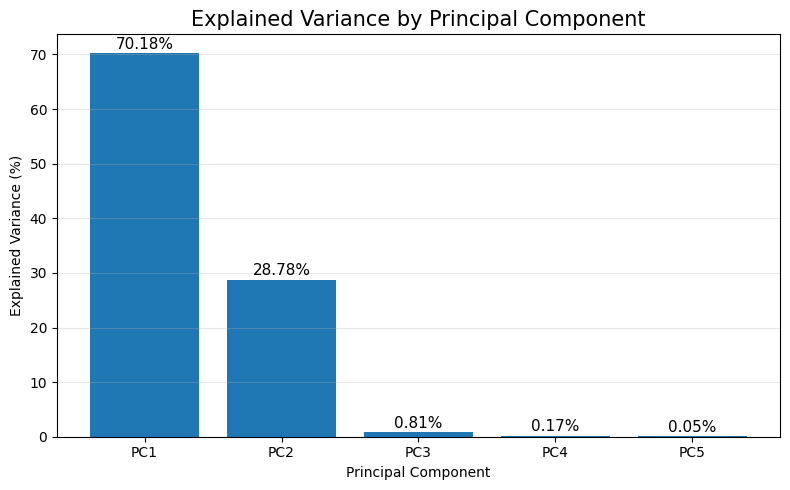

In [43]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    explained["Principal Component"],
    explained["Explained Variance (%)"]
)

# Labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f"{height:.2f}%",
        ha="center",
        fontsize=11
    )

plt.title("Explained Variance by Principal Component", fontsize=15)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/figure6_pca_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 6.** Explained variance of the principal components derived from the standardized U.S. Treasury yield curve during Q2 2026. The first two principal components account for approximately **98.96%** of the total variation in Treasury yields, indicating that yield-curve movements during the quarter were primarily driven by two dominant underlying factors.

### Interpretation

The first principal component (PC1) explains **70.18%** of the total variation in Treasury yields during Q2 2026, while the second principal component (PC2) explains **28.78%**. Together, these two components account for **98.96%** of all observed movements in the yield curve.

The remaining principal components (PC3–PC5) explain just **1.03%** of the total variation, indicating that nearly all changes in Treasury yields during the quarter can be summarized by the first two principal components.

### Key Findings

- **PC1** explains **70.18%** of total yield-curve variation.
- **PC2** explains **28.78%** of total yield-curve variation.
- **PC1 and PC2 together explain 98.96%** of all observed Treasury yield movements.
- **PC3–PC5 collectively explain only 1.03%**, indicating that higher-order factors contributed minimally during Q2 2026.

### Next Step

While the explained variance identifies **how much** of the yield-curve movement is captured by each principal component, it does not reveal **what each component represents economically**.

The next section examines the **principal component loading matrix** to determine whether the dominant components correspond to the traditional **Level**, **Slope**, and **Curvature** factors used in fixed-income analysis.

## 6.3 Principal Component Loadings

The loading matrix shows how strongly each Treasury maturity contributes to each principal component. By examining the sign and magnitude of these loadings, we can determine the economic interpretation of each principal component.

In fixed-income analysis, the first three principal components are commonly associated with:

- **Level:** Parallel shifts in Treasury yields across all maturities.
- **Slope:** Changes in the difference between short-term and long-term yields.
- **Curvature:** Changes in the shape or bend of the yield curve.

### 6.3.1 Compute the Loading Matrix

In [44]:
# Computing PCA loading matrix

loadings = pd.DataFrame(
    pca.components_.T,
    index=["3M","2Y","5Y","10Y","30Y"],
    columns=["PC1","PC2","PC3","PC4","PC5"]
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
3M,0.226,0.748,0.623,-0.012,-0.029
2Y,0.509,0.235,-0.446,0.677,0.170
5Y,0.530,0.064,-0.307,-0.463,-0.637
10Y,0.517,-0.200,0.076,-0.446,0.699
30Y,0.375,-0.584,0.559,0.359,-0.277


### 6.3.2 Visualize the Loadings

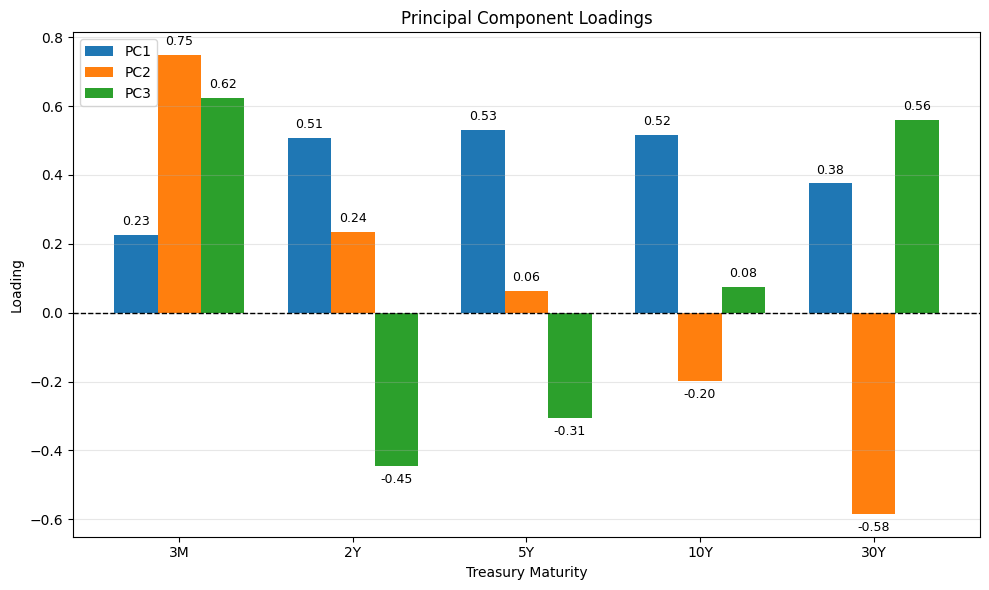

In [45]:
plt.figure(figsize=(10,6))

x = np.arange(len(loadings.index))
width = 0.25

bars1 = plt.bar(x - width, loadings["PC1"], width, label="PC1")
bars2 = plt.bar(x,         loadings["PC2"], width, label="PC2")
bars3 = plt.bar(x + width, loadings["PC3"], width, label="PC3")

# Add value labels above each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        if height >= 0:
            y = height + 0.02
            va = "bottom"
        else:
            y = height - 0.02
            va = "top"

        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{height:.2f}",
            ha="center",
            va=va,
            fontsize=9
        )

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xticks(x, loadings.index)

plt.title("Principal Component Loadings")
plt.xlabel("Treasury Maturity")
plt.ylabel("Loading")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/figure7_pca_loadings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 7.** Principal component loadings across Treasury maturities for the first three principal components derived from the standardized yield curve during Q2 2026. The loading patterns show how each maturity contributes to the dominant sources of variation in Treasury yields and provide the basis for interpreting the components as the traditional **Level**, **Slope**, and **Curvature** factors.

### Interpretation

The loading matrix provides an economic interpretation of the principal components identified by the PCA.

The **first principal component (PC1)** exhibits positive loadings across all Treasury maturities, with the largest contributions coming from the intermediate segment of the yield curve (2Y–10Y). This common positive pattern indicates that PC1 captures broad movements in interest rates and is consistent with the traditional **Level factor**, representing parallel shifts in the yield curve.

The **second principal component (PC2)** displays positive loadings for shorter maturities and negative loadings for longer maturities. This opposing pattern is characteristic of the **Slope factor**, capturing changes in the steepness of the yield curve as short-term and long-term yields move in opposite directions. The strong positive loading on the 3-month Treasury and strong negative loading on the 30-year Treasury indicate that this factor played an important role during Q2 2026.

The **third principal component (PC3)** alternates between positive and negative loadings across maturities, with positive loadings at the short and long ends of the curve and negative loadings concentrated in the intermediate maturities. This pattern is consistent with the **Curvature factor**, reflecting localized changes in the shape of the yield curve rather than broad parallel movements.

### Key Findings

- **PC1 (Level):** Positive loadings across all maturities indicate that Treasury yields largely moved together during Q2 2026, capturing broad shifts in the overall level of interest rates.

- **PC2 (Slope):** Positive loadings for short-term maturities and negative loadings for long-term maturities indicate changes in the steepness of the yield curve, consistent with the flattening observed earlier in the analysis.

- **PC3 (Curvature):** Alternating positive and negative loadings indicate localized changes in the shape of the yield curve, although this factor contributed relatively little to total variation.

- Combined with the explained variance analysis, the loading matrix shows that **Q2 Treasury market movements were driven primarily by Level and Slope factors**, while Curvature played only a minor role.

### PCA Summary

Principal Component Analysis confirms the conclusions reached in the earlier sections of this report. The Treasury yield curve during Q2 2026 was primarily influenced by broad changes in the overall level of interest rates and shifts in the slope of the curve. Together, these two factors explained approximately **99%** of all observed yield-curve movements, reinforcing the view that the quarter was characterized by a broad repricing of interest rates alongside a meaningful flattening of the yield curve.

# 7. Macroeconomic Event Analysis

Treasury yields are influenced by a broad range of macroeconomic developments, including monetary policy decisions, inflation releases, labor market conditions, and economic growth data.

This section places the quantitative findings from the previous analyses into their broader macroeconomic context by highlighting several key events during Q2 2026 that likely influenced Treasury market expectations.

## 7.1 Major Macroeconomic Events

In [46]:
events = pd.DataFrame({
    "Date": [
        "April 29, 2026",
        "May 12, 2026",
        "June 10, 2026",
        "June 17, 2026"
    ],
    "Event": [
        "FOMC Policy Decision",
        "April Consumer Price Index Release",
        "May Consumer Price Index Release",
        "FOMC Policy Decision"
    ],
    "Potential Market Impact": [
        "Federal Reserve policy guidance influenced expectations for the future path of short-term interest rates.",
        "The inflation release affected expectations for monetary policy and Treasury yields.",
        "The inflation release contributed to the reassessment of inflation and Federal Reserve policy expectations.",
        "The policy decision and accompanying guidance influenced Treasury yields and the shape of the yield curve."
    ]
})

events

,Date,Event,Potential Market Impact
0,"April 29, 2026",FOMC Policy Decision,Federal Reserve policy guidance influenced exp...
1,"May 12, 2026",April Consumer Price Index Release,The inflation release affected expectations fo...
2,"June 10, 2026",May Consumer Price Index Release,The inflation release contributed to the reass...
3,"June 17, 2026",FOMC Policy Decision,The policy decision and accompanying guidance ...


### Event Selection

The event timeline highlights two Federal Reserve policy decisions and two major inflation releases during Q2 2026. These events were selected because monetary-policy communication and inflation data are important drivers of Treasury yields, particularly at the short and intermediate portions of the yield curve.

## 7.2 Market Response to Key Events

To assess the Treasury market response around each major macroeconomic event, the analysis calculates the one-day change in the 2-year and 10-year Treasury yields from the previous available trading day to the event date.

Yield changes are reported in basis points. The change in the 2Y–10Y spread is also included to indicate whether the curve steepened or flattened around each event.

These calculations describe the market movement associated with each date but do not, by themselves, establish that the event was the sole cause of the change.

### Preparing the event dates

In [47]:
# Converting event dates to datetime
events["Event Date"] = pd.to_datetime(events["Date"])

# Keep the columns needed for the event analysis
event_analysis = events[
    ["Event Date", "Event", "Potential Market Impact"]
].copy()

event_analysis

,Event Date,Event,Potential Market Impact
0,2026-04-29,FOMC Policy Decision,Federal Reserve policy guidance influenced exp...
1,2026-05-12,April Consumer Price Index Release,The inflation release affected expectations fo...
2,2026-06-10,May Consumer Price Index Release,The inflation release contributed to the reass...
3,2026-06-17,FOMC Policy Decision,The policy decision and accompanying guidance ...


### Calculating event-day yield changes

In [48]:
event_results = []

for _, row in event_analysis.iterrows():
    event_date = row["Event Date"]

    # Use only observations on or before the event date
    available_dates = yields.index[yields.index <= event_date]

    if len(available_dates) < 2:
        continue

    actual_event_date = available_dates[-1]
    previous_trading_date = available_dates[-2]

    # Event-day yields
    event_2y = yields.loc[actual_event_date, "2Y"]
    event_10y = yields.loc[actual_event_date, "10Y"]
    event_spread = yields.loc[actual_event_date, "2Y_10Y_Spread"]

    # Previous-trading-day yields
    previous_2y = yields.loc[previous_trading_date, "2Y"]
    previous_10y = yields.loc[previous_trading_date, "10Y"]
    previous_spread = yields.loc[
        previous_trading_date,
        "2Y_10Y_Spread"
    ]

    # Changes in basis points
    change_2y = (event_2y - previous_2y) * 100
    change_10y = (event_10y - previous_10y) * 100
    spread_change = (event_spread - previous_spread) * 100

    # Classify the curve movement
    if spread_change > 0:
        curve_move = "Steepening"
    elif spread_change < 0:
        curve_move = "Flattening"
    else:
        curve_move = "Unchanged"

    event_results.append({
        "Event Date": actual_event_date,
        "Previous Trading Day": previous_trading_date,
        "Event": row["Event"],
        "2Y Change (bps)": round(change_2y, 1),
        "10Y Change (bps)": round(change_10y, 1),
        "2Y–10Y Spread Change (bps)": round(spread_change, 1),
        "Curve Movement": curve_move
    })

market_response = pd.DataFrame(event_results)

market_response

,Event Date,Previous Trading Day,Event,2Y Change (bps),10Y Change (bps),2Y–10Y Spread Change (bps),Curve Movement
0,2026-04-29,2026-04-28,FOMC Policy Decision,8.0,6.0,-2.0,Flattening
1,2026-05-12,2026-05-11,April Consumer Price Index Release,5.0,4.0,-1.0,Flattening
2,2026-06-10,2026-06-09,May Consumer Price Index Release,0.0,2.0,2.0,Steepening
3,2026-06-17,2026-06-16,FOMC Policy Decision,15.0,6.0,-9.0,Flattening


### Figure 8: Event-day yield changes

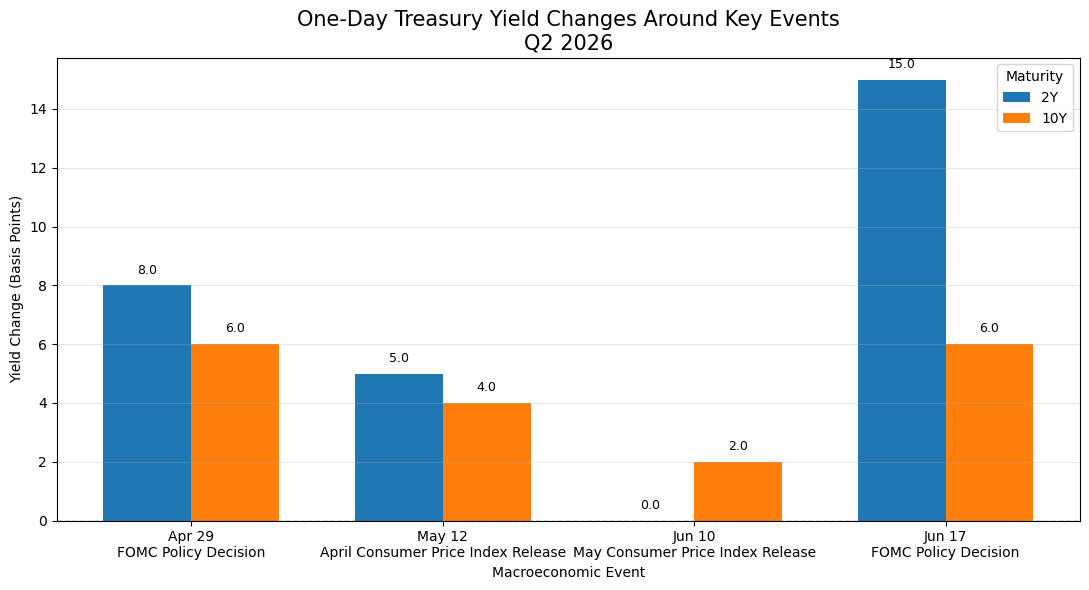

In [49]:
event_labels = (
    pd.to_datetime(market_response["Event Date"])
    .dt.strftime("%b %d")
    + "\n"
    + market_response["Event"]
)

x = np.arange(len(market_response))
width = 0.35

plt.figure(figsize=(11, 6))

bars_2y = plt.bar(
    x - width / 2,
    market_response["2Y Change (bps)"],
    width,
    label="2Y"
)

bars_10y = plt.bar(
    x + width / 2,
    market_response["10Y Change (bps)"],
    width,
    label="10Y"
)

plt.axhline(0, linewidth=1, linestyle="--")

plt.xticks(x, event_labels)
plt.title(
    "One-Day Treasury Yield Changes Around Key Events\nQ2 2026",
    fontsize=15
)
plt.xlabel("Macroeconomic Event")
plt.ylabel("Yield Change (Basis Points)")
plt.legend(title="Maturity")
plt.grid(axis="y", alpha=0.3)

# Add values to each bar
for bars in [bars_2y, bars_10y]:
    for bar in bars:
        height = bar.get_height()

        if height >= 0:
            y_position = height + 0.3
            vertical_alignment = "bottom"
        else:
            y_position = height - 0.3
            vertical_alignment = "top"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y_position,
            f"{height:.1f}",
            ha="center",
            va=vertical_alignment,
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "charts/figure8_event_day_yield_changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 8.** One-day changes in the 2-year and 10-year Treasury yields surrounding selected Federal Reserve policy decisions and Consumer Price Index (CPI) releases during Q2 2026. The figure illustrates how different macroeconomic events influenced Treasury yields across the short and intermediate segments of the yield curve.

## 7.3 Discussion

The event-response analysis demonstrates that Treasury yields reacted differently to major macroeconomic events during Q2 2026, with the largest responses generally occurring at the short end of the yield curve.

Both Federal Reserve policy decisions were associated with notable increases in Treasury yields. Following the **April 29 FOMC meeting**, the 2-year Treasury yield increased by **8 basis points**, while the 10-year yield rose by **6 basis points**, producing a modest **2-basis-point flattening** of the yield curve.

The **April CPI release (May 12)** generated a similar but smaller response, with the 2-year yield rising **5 basis points** and the 10-year yield increasing **4 basis points**, resulting in an additional **1-basis-point flattening**.

The **May CPI release (June 10)** produced a different pattern. The 2-year Treasury yield remained unchanged while the 10-year yield increased **2 basis points**, temporarily steepening the yield curve by **2 basis points**. This suggests that investors revised longer-term expectations more than near-term monetary policy expectations on that day.

The strongest market response occurred following the **June 17 FOMC meeting**. The 2-year Treasury yield increased **15 basis points**, compared with a **6-basis-point** increase in the 10-year yield, producing a significant **9-basis-point flattening** of the yield curve. This was the largest single-day adjustment among the selected events and indicates that the market substantially revised expectations for the future path of short-term interest rates.

## 7.4 Linking the Evidence

The various analyses conducted throughout this report present a consistent picture of Treasury market dynamics during Q2 2026.

The time-series analysis showed that Treasury yields increased across nearly all maturities over the quarter, with the largest increases occurring in the **2-year (+33 basis points)** and **5-year (+22 basis points)** maturities. In contrast, the **30-year Treasury yield remained essentially unchanged**, indicating that repricing was concentrated primarily in the short and intermediate portions of the curve.

The 2Y–10Y spread narrowed from **52 basis points** at the beginning of Q2 to **30 basis points** by quarter-end, representing a **22-basis-point flattening**. This indicates that short-term interest rates increased more rapidly than long-term rates.

The rolling-volatility analysis further showed that interest-rate uncertainty peaked during the middle of the quarter, particularly in the **5-year Treasury**, before gradually declining toward the end of June.

Principal Component Analysis confirmed these findings. The first two principal components explained **98.96%** of total yield-curve variation, while the loading patterns identified them as the traditional **Level** and **Slope** factors. This indicates that Q2 Treasury movements were driven primarily by broad changes in interest rates together with meaningful adjustments in the steepness of the yield curve.

Finally, the event-response analysis links these broader market trends to specific macroeconomic developments. Both Federal Reserve policy decisions were associated with yield-curve flattening, while inflation releases produced more moderate and mixed responses. The particularly strong reaction following the **June 17 FOMC meeting** supports the conclusion that changing expectations for monetary policy were a major driver of Treasury market movements during Q2 2026.

Taken together, the evidence suggests that Q2 2026 was characterized by a broad upward repricing of Treasury yields, concentrated at shorter maturities, accompanied by a meaningful flattening of the yield curve as markets adjusted expectations for future Federal Reserve policy.

# 8. Conclusions & Q3 Outlook

This section summarizes the key findings from the analysis and discusses their implications for the U.S. Treasury market heading into the next quarter.

## 8.1 Executive Summary

This study examined the evolution of the U.S. Treasury yield curve during Q2 2026 using daily Treasury yields from the Federal Reserve Economic Data (FRED) database.

The analysis found that Treasury yields generally moved higher during the quarter, with the largest increases concentrated in the short- and intermediate-term maturities. As a result, the yield curve flattened as the 2-year Treasury yield increased substantially more than the 10-year and 30-year maturities.

Additional analysis of rolling volatility indicated that market uncertainty peaked during the middle of the quarter before gradually subsiding. Principal Component Analysis further showed that nearly all Treasury yield movements could be explained by the traditional **Level** and **Slope** factors, while Curvature played only a minor role.

Finally, the event-study analysis demonstrated that Federal Reserve policy decisions produced the largest one-day movements in Treasury yields, particularly at the short end of the curve, reinforcing the importance of monetary policy expectations in shaping fixed-income markets during Q2 2026.

## 8.2 Key Findings

The analysis produced several notable findings:

- Treasury yields increased across nearly all maturities during Q2 2026.
- The **2-year Treasury yield** experienced the largest increase, rising **33 basis points** over the quarter.
- The **2Y–10Y spread** narrowed by **22 basis points**, indicating a meaningful flattening of the yield curve.
- Rolling volatility peaked during mid-May before moderating toward quarter-end.
- Principal Component Analysis showed that **98.96%** of Treasury yield movements were explained by the first two principal components, corresponding to the traditional **Level** and **Slope** factors.
- Federal Reserve policy decisions generated the largest event-day movements in Treasury yields during the quarter.

## 8.3 Investment Implications

The observed flattening of the Treasury yield curve suggests that investors revised expectations for near-term monetary policy more aggressively than long-term inflation or economic growth expectations.

The concentration of volatility in the intermediate segment of the yield curve indicates that this portion of the market was particularly sensitive to changes in policy expectations throughout Q2.

For fixed-income investors and risk managers, these findings highlight the importance of monitoring both Federal Reserve communications and inflation data, as these events can materially influence Treasury yields and portfolio interest-rate risk.

## 8.4 Risks to Monitor in Q3

Several factors are likely to influence Treasury markets during the upcoming quarter:

- Future Federal Reserve policy decisions and forward guidance.
- Inflation developments, particularly CPI and PCE inflation reports.
- Labor market conditions, including monthly employment reports.
- Economic growth indicators such as GDP and retail sales.
- Changes in Treasury issuance and market liquidity.
- Geopolitical developments that may affect demand for U.S. government securities.

These factors will continue to shape investor expectations regarding interest rates and the future evolution of the Treasury yield curve.

## 8.5 Limitations

This analysis focuses on one quarter of Treasury market data and therefore reflects short-term market dynamics rather than long-run structural relationships. While the event-study analysis identifies yield movements surrounding selected macroeconomic events, it does not establish causal relationships because multiple factors may influence Treasury yields simultaneously.

Future work could extend the analysis by incorporating longer sample periods, additional macroeconomic variables, or higher-frequency intraday data to better isolate the effects of specific economic announcements.

## 8.6 Future Research

Several extensions could build upon this analysis:

- Compare Treasury yield dynamics across multiple quarters or business-cycle phases.
- Incorporate inflation expectations and real Treasury yields (TIPS).
- Analyze Treasury futures alongside cash Treasury yields.
- Develop forecasting models for the 2Y–10Y spread using macroeconomic variables.
- Investigate how Treasury yield factors influence equity, credit, and foreign exchange markets.

## Final Thoughts

The U.S. Treasury market provides one of the clearest real-time measures of investor expectations regarding monetary policy, inflation, and economic growth. By combining yield-curve analysis, spread dynamics, volatility measures, principal component analysis, and macroeconomic event studies, this project demonstrates how quantitative techniques can be used to better understand the forces driving fixed-income markets.

This notebook serves as a foundation for future quarterly Treasury market reviews and highlights the value of integrating statistical analysis with macroeconomic interpretation in quantitative rates research.